# Phase 4–6: Ranking Models, Ablation and Analysis

Random Forest and Two-Tower trained on visited (1) vs unvisited (0) cities, scored by ranking ~276 candidate
cities per test user (Recall@10, NDCG@10, MRR@10). Four feature configs answer the research questions:
**Baseline**, **+Weather** (RQ1), **+Embeddings** (RQ2), **Full** (RQ3); RF vs Two-Tower answers RQ4.
Charts are saved to `reports/figures/`.

In [1]:
import sys
sys.path.insert(0, '../../')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from config import *
from src.data.cache import DataCache
from src.evaluation.harness import RecommendationHarness
from src.features.ranking_features import (
    USER_FEATURES, CITY_FEATURES, PAIR_FEATURES, WEATHER_FEATURES, TEXT_FEATURES,
    city_features, user_features, trip_months, city_month_weather, build_pair_features,
)
from src.features.review_embeddings import user_text_vectors, city_text_vectors, text_features
from src.features.weather_features import WeatherFeatureBuilder
from src.models.baselines import PopularityBaseline
from src.models.rankers import RandomForestRanker, TwoTowerRanker

cache = DataCache(str(CACHE_DIR))
businesses = cache.load_dataframe('businesses_major_cities')
reviews = cache.load_dataframe('reviews_cross_city')

/Users/nomin/Downloads/ML Lab/project/ML-Project/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Same test users as Phase 1; validation users are carved out of train for tuning
harness = RecommendationHarness(
    reviews,
    businesses,
    test_size=PHASE1_TEST_SIZE,
    val_size=PHASE1_VAL_SIZE,
    random_state=RANDOM_STATE,
    n_negatives=PHASE1_NEGATIVES_PER_POSITIVE
)
train_reviews, test_reviews = harness.create_train_test_split()
all_cities = sorted(businesses['city'].unique())
train_labels = harness.get_training_labels(all_cities)
val_pairs = harness.get_validation_pairs()
test_pairs = harness.get_test_pairs()

print(f"Users: train {len(harness.train_users):,} · val {len(harness.val_users):,} · test {len(harness.test_users):,}")
print(f"Training rows: {len(train_labels):,}")

Users: train 6,886 · val 984 · test 1,968
Training rows: 34,430


In [3]:
# Features: user history, city stats, distance, trip-month weather, review text (history only)
history = pd.concat([train_reviews, harness.val_reviews, test_reviews])
cities = city_features(businesses)
users = user_features(history, businesses, cities)
months = trip_months(reviews, businesses, harness.targets)
weather = city_month_weather(cities, WeatherFeatureBuilder(cache_dir=WEATHER_CACHE))

encoder = SentenceTransformer(EMBEDDING_MODEL)
text = text_features(user_text_vectors(history, encoder), city_text_vectors(history, businesses, encoder))
train_df = build_pair_features(train_labels, users, cities, months, weather, text)

print(f"Weather: {len(weather):,} city-months · review vectors: {len(text['user_pcs']):,} users, {len(text['city_pcs']):,} cities")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8243.43it/s]

Weather: 3,372 city-months · review vectors: 9,838 users, 281 cities


In [4]:
def scorer(model):
    """Turn a fitted model into a score function over (user_id, city) candidate rows."""
    return lambda candidates: model.score(build_pair_features(candidates, users, cities, months, weather, text))

def evaluate(score_fn, pairs=test_pairs, per_user=False):
    return harness.evaluate(pairs, all_cities, score_fn, k=PHASE1_EVAL_K, per_user=per_user)

RECALL = f'recall@{PHASE1_EVAL_K}'
popularity = PopularityBaseline(businesses, history)
popularity_scores = {city: popularity.score_city(city) for city in all_cities}
rng = np.random.default_rng(RANDOM_STATE)

results = {
    'Random': evaluate(lambda c: rng.random(len(c))),
    'Popularity': evaluate(lambda c: c['city'].map(popularity_scores).to_numpy()),
}
pd.DataFrame(results).T.round(3)

,recall@10,ndcg@10,mrr@10,num_queries
Random,0.038,0.018,0.013,1968.0
Popularity,0.358,0.180,0.126,1968.0


In [5]:
# Four feature configs: RF features, Two-Tower user-tower inputs, Two-Tower city-tower inputs
base = USER_FEATURES + CITY_FEATURES + PAIR_FEATURES
user_pcs, city_pcs = list(text['user_pcs'].columns), list(text['city_pcs'].columns)
city_weather = ['city_temp', 'city_precip']
configs = {
    'Baseline': (base, USER_FEATURES, CITY_FEATURES),
    '+Weather': (base + WEATHER_FEATURES, USER_FEATURES, CITY_FEATURES + city_weather),
    '+Embeddings': (base + TEXT_FEATURES, USER_FEATURES + user_pcs, CITY_FEATURES + city_pcs),
    'Full': (base + WEATHER_FEATURES + TEXT_FEATURES, USER_FEATURES + user_pcs, CITY_FEATURES + city_weather + city_pcs),
}

# Random Forest: tree depth picked once on validation users
val_by_depth = {}
for depth in [8, 15]:
    rf = RandomForestRanker(base, RF_N_ESTIMATORS, depth, RF_RANDOM_STATE).fit(train_df)
    val_by_depth[depth] = evaluate(scorer(rf), val_pairs)[RECALL]
best_depth = max(val_by_depth, key=val_by_depth.get)
print(f"Validation Recall@10 by depth: {val_by_depth} -> depth {best_depth}")

models, val_recall = {}, {}
for name, (rf_cols, _, _) in configs.items():
    rf = RandomForestRanker(rf_cols, RF_N_ESTIMATORS, best_depth, RF_RANDOM_STATE).fit(train_df)
    models[('Random Forest', name)] = rf
    val_recall[('Random Forest', name)] = evaluate(scorer(rf), val_pairs)[RECALL]
    results[f'Random Forest · {name}'] = evaluate(scorer(rf))

Validation Recall@10 by depth: {8: np.float64(0.6941056910569106), 15: np.float64(0.6910569105691057)} -> depth 8


In [6]:
# Two-Tower: best epoch picked on validation Recall@10
val_fn = lambda model: evaluate(scorer(model), val_pairs)[RECALL]
for name, (_, user_cols, city_cols) in configs.items():
    tt = TwoTowerRanker(
        user_cols, city_cols, TOWER_HIDDEN_DIM, TOWER_EMBEDDING_DIM, TOWER_LEARNING_RATE, epochs=TOWER_EPOCHS
    ).fit(train_df, val_fn)
    models[('Two-Tower', name)] = tt
    val_recall[('Two-Tower', name)] = max(tt.history)
    results[f'Two-Tower · {name}'] = evaluate(scorer(tt))

table = pd.DataFrame(results).T.drop(columns='num_queries').round(3)
print(f"Test users: {len(test_pairs):,}")
table

Test users: 1,968


,recall@10,ndcg@10,mrr@10
Random,0.038,0.018,0.013
Popularity,0.358,0.180,0.126
Random Forest · Baseline,0.723,0.541,0.484
Random Forest · +Weather,0.720,0.539,0.483
Random Forest · +Embeddings,0.725,0.540,0.483
Random Forest · Full,0.725,0.543,0.486
Two-Tower · Baseline,0.634,0.432,0.370
Two-Tower · +Weather,0.633,0.435,0.373
Two-Tower · +Embeddings,0.625,0.428,0.366
Two-Tower · Full,0.632,0.435,0.373


In [7]:
# Ablation view: Recall@10 by feature config and model
ablation = pd.DataFrame({
    model: [results[f'{model} · {name}'][RECALL] for name in configs]
    for model in ['Random Forest', 'Two-Tower']
}, index=list(configs)).round(3)
ablation

,Random Forest,Two-Tower
Baseline,0.723,0.634
+Weather,0.720,0.633
+Embeddings,0.725,0.625
Full,0.725,0.632


In [8]:
# Error analysis: best model on validation, Recall@10 by distance from home to the hidden city
best_key = max(val_recall, key=val_recall.get)
best_model = models[best_key]
print(f"Best on validation: {best_key[0]} · {best_key[1]}")

per_user = evaluate(scorer(best_model), per_user=True)
distance = build_pair_features(
    pd.DataFrame(test_pairs, columns=['user_id', 'city']), users, cities, months
).set_index('user_id')['distance_km']
per_user['trip'] = pd.cut(
    per_user['user_id'].map(distance), [-1, 50, 500, np.inf],
    labels=['under 50 km', '50–500 km', 'over 500 km']
)
by_distance = per_user.groupby('trip', observed=True)['recall@k'].agg(['mean', 'size']).round(3)
by_distance

Best on validation: Random Forest · Full


,mean,size
trip,,
under 50 km,0.766,1597
50–500 km,0.275,51
over 500 km,0.588,320


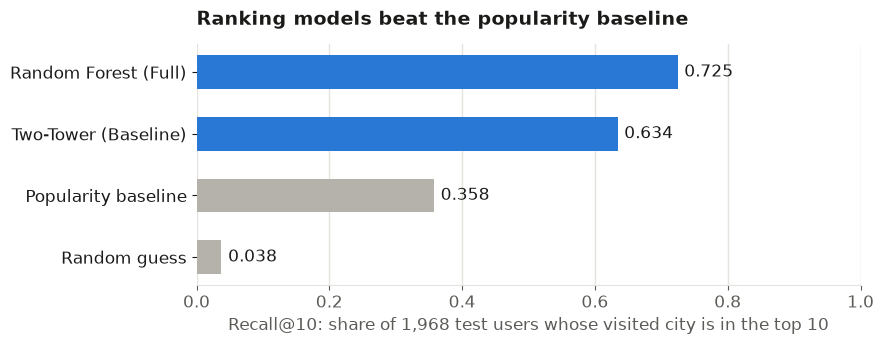

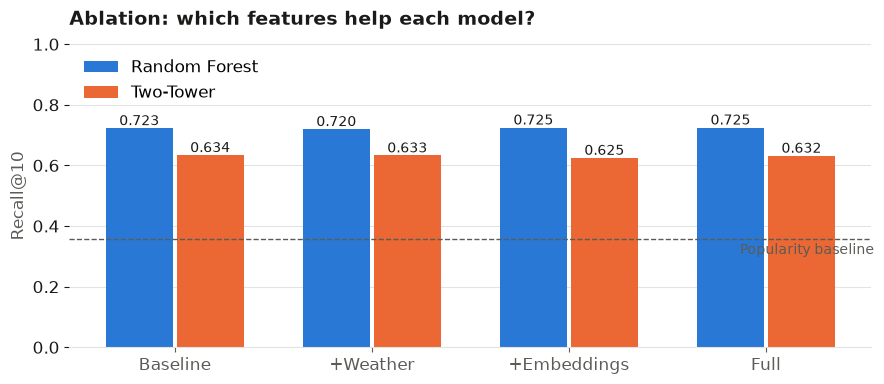

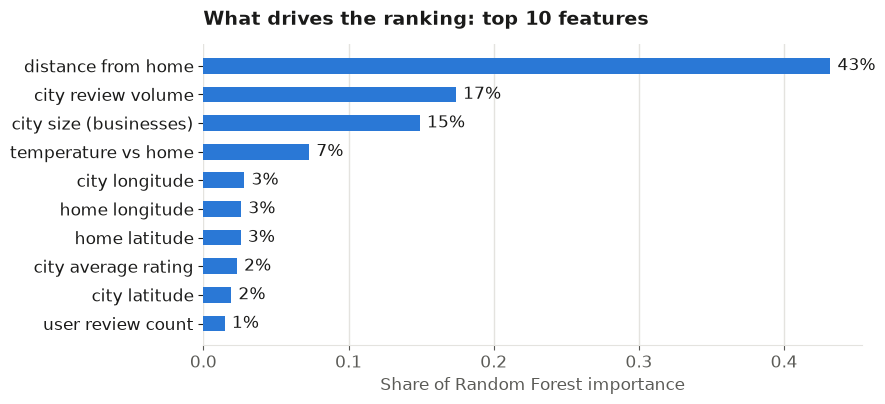

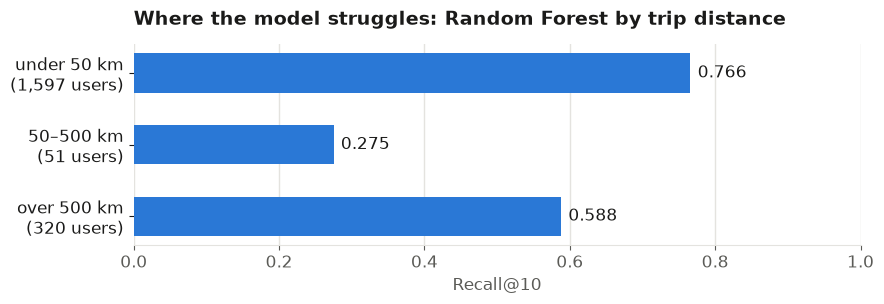

In [9]:
# Charts (light theme, saved to reports/figures/)
FIG_DIR = FIGURE_DIR
FIG_DIR.mkdir(parents=True, exist_ok=True)
INK, MUTED, GRID = '#1a1a19', '#5b5b57', '#e4e3df'
BLUE, ORANGE, GRAY = '#2a78d6', '#eb6834', '#b4b2ab'
plt.rcParams.update({'font.size': 12, 'axes.edgecolor': GRID, 'axes.labelcolor': MUTED,
                     'xtick.color': MUTED, 'ytick.color': INK, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.spines.left': False})

def finish(ax, title, path):
    ax.set_title(title, loc='left', fontsize=14, fontweight='bold', color=INK, pad=14)
    ax.xaxis.grid(True, color=GRID, linewidth=1)
    ax.set_axisbelow(True)
    ax.figure.tight_layout()
    ax.figure.savefig(FIG_DIR / path, dpi=200)

# 1. Recall@10 by model (each model's config picked on validation, not test)
rf_best = max(configs, key=lambda n: val_recall[('Random Forest', n)])
tt_best = max(configs, key=lambda n: val_recall[('Two-Tower', n)])
bars = {
    f'Random Forest ({rf_best})': results[f'Random Forest · {rf_best}'][RECALL],
    f'Two-Tower ({tt_best})': results[f'Two-Tower · {tt_best}'][RECALL],
    'Popularity baseline': results['Popularity'][RECALL],
    'Random guess': results['Random'][RECALL],
}
fig, ax = plt.subplots(figsize=(9, 3.6))
names = list(bars)[::-1]
ax.barh(names, [bars[n] for n in names], height=0.55, color=[GRAY, GRAY, BLUE, BLUE])
for i, n in enumerate(names):
    ax.text(bars[n] + 0.01, i, f'{bars[n]:.3f}', va='center', color=INK)
ax.set_xlim(0, 1)
ax.set_xlabel(f'Recall@10: share of {len(test_pairs):,} test users whose visited city is in the top 10')
finish(ax, 'Ranking models beat the popularity baseline', 'recall_by_model.png')

# 2. Ablation: grouped bars, RF vs Two-Tower per config
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(configs))
ax.bar(x - 0.18, ablation['Random Forest'], 0.34, color=BLUE, label='Random Forest')
ax.bar(x + 0.18, ablation['Two-Tower'], 0.34, color=ORANGE, label='Two-Tower')
for i, name in enumerate(configs):
    ax.text(i - 0.18, ablation.loc[name, 'Random Forest'] + 0.01, f"{ablation.loc[name, 'Random Forest']:.3f}", ha='center', color=INK, fontsize=10)
    ax.text(i + 0.18, ablation.loc[name, 'Two-Tower'] + 0.01, f"{ablation.loc[name, 'Two-Tower']:.3f}", ha='center', color=INK, fontsize=10)
ax.axhline(results['Popularity'][RECALL], color=MUTED, linestyle='--', linewidth=1)
ax.text(len(configs) - 0.45, results['Popularity'][RECALL] - 0.05, 'Popularity baseline', ha='right', color=MUTED, fontsize=10)
ax.set_xticks(x, list(configs))
ax.set_ylim(0, 1)
ax.set_ylabel('Recall@10')
ax.legend(frameon=False, loc='upper left')
ax.xaxis.grid(False)
ax.yaxis.grid(True, color=GRID)
ax.set_title('Ablation: which features help each model?', loc='left', fontsize=14, fontweight='bold', color=INK, pad=14)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(FIG_DIR / 'ablation.png', dpi=200)

# 3. Feature importance (Random Forest, Full config)
readable = {
    'distance_km': 'distance from home', 'city_log_reviews': 'city review volume',
    'city_log_businesses': 'city size (businesses)', 'temp_diff': 'temperature vs home',
    'city_temp': 'city temperature', 'city_precip': 'city rainfall', 'text_similarity': 'review text similarity',
    'city_avg_stars': 'city average rating', 'lat': 'city latitude', 'lon': 'city longitude',
    'home_lat': 'home latitude', 'home_lon': 'home longitude', 'user_avg_stars': 'user average rating',
    'user_std_stars': 'user rating spread', 'user_log_reviews': 'user review count', 'user_num_cities': 'user cities visited',
}
importance = pd.Series(models[('Random Forest', 'Full')].feature_importance()).rename(readable).sort_values().tail(10)
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(importance.index, importance.values, height=0.55, color=BLUE)
for i, v in enumerate(importance.values):
    ax.text(v + 0.005, i, f'{v:.0%}', va='center', color=INK)
ax.set_xlabel('Share of Random Forest importance')
finish(ax, 'What drives the ranking: top 10 features', 'feature_importance.png')

# 4. Recall@10 by trip distance (best model)
fig, ax = plt.subplots(figsize=(9, 3.2))
labels = [f'{trip}\n({int(n):,} users)' for trip, n in by_distance['size'].items()][::-1]
values = by_distance['mean'].values[::-1]
ax.barh(labels, values, height=0.55, color=BLUE)
for i, v in enumerate(values):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', color=INK)
ax.set_xlim(0, 1)
ax.set_xlabel('Recall@10')
finish(ax, f'Where the model struggles: {best_key[0]} by trip distance', 'recall_by_distance.png')
plt.show()

In [10]:
cache.save_metadata({
    'test_users': len(test_pairs),
    'results': table.to_dict(orient='index'),
    'ablation_recall@10': ablation.to_dict(),
    'best_model': ' · '.join(best_key),
    'recall_by_distance': by_distance.to_dict(orient='index'),
}, 'ranking_results')
print('✓ Results and charts saved')

✓ Results and charts saved
